In [1]:
# Data preparation
import pandas as pd
train = pd.read_csv("yelp242a_train.csv")
test = pd.read_csv("yelp242a_test.csv")

train['fourOrAbove'] = (train['stars'] >= 4).astype(int)
test['fourOrAbove'] = (test['stars'] >= 4).astype(int)

**Problem 2 - b) - i)**

In [2]:
# Encode categorical variables for training data
from sklearn.preprocessing import OneHotEncoder
import numpy as np

categorical_cols = ['GoodForKids', 'Alcohol', 'BusinessAcceptsCreditCards', 'WiFi', 'BikeParking', 
                    'ByAppointmentOnly', 'WheelechairAccessible', 'OutdoorSeating', 'RestaurantsReservations', 'DogsAllowed', 'Caters']

for col in categorical_cols:
    train[col] = train[col].replace({np.nan: '(Missing)'}).astype(str).str.replace("'", "", regex=False)

train['GoodForKids'] = pd.Categorical(train['GoodForKids'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['Alcohol'] = pd.Categorical(train['Alcohol'], categories=['(Missing)', 'beer_and_wine', 'full_bar', 'none'])
train['BusinessAcceptsCreditCards'] = pd.Categorical(train['BusinessAcceptsCreditCards'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['WiFi'] = pd.Categorical(train['WiFi'], categories=['(Missing)', 'free', 'no', 'paid'])
train['BikeParking'] = pd.Categorical(train['BikeParking'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['ByAppointmentOnly'] = pd.Categorical(train['ByAppointmentOnly'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['WheelechairAccessible'] = pd.Categorical(train['WheelechairAccessible'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['OutdoorSeating'] = pd.Categorical(train['OutdoorSeating'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['RestaurantsReservations'] = pd.Categorical(train['RestaurantsReservations'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['DogsAllowed'] = pd.Categorical(train['DogsAllowed'], categories=['(Missing)', 'FALSE', 'TRUE'])
train['Caters'] = pd.Categorical(train['Caters'], categories=['(Missing)', 'FALSE', 'TRUE'])

encoder_good = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Good_encoded = encoder_good.fit_transform(train[['GoodForKids']])

encoder_alcohol = OneHotEncoder(categories=[['(Missing)', 'beer_and_wine', 'full_bar', 'none']], drop='first', sparse_output=False)
Alcohol_encoded = encoder_alcohol.fit_transform(train[['Alcohol']])

encoder_biz = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Biz_encoded = encoder_biz.fit_transform(train[['BusinessAcceptsCreditCards']])

encoder_wifi = OneHotEncoder(categories=[['(Missing)', 'free', 'no', 'paid']], drop='first', sparse_output=False)
WiFi_encoded = encoder_wifi.fit_transform(train[['WiFi']])

encoder_bike = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Bike_encoded = encoder_bike.fit_transform(train[['BikeParking']])

encoder_appoint = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Appoint_encoded = encoder_appoint.fit_transform(train[['ByAppointmentOnly']])

encoder_wheel = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Wheel_encoded = encoder_wheel.fit_transform(train[['WheelechairAccessible']])

encoder_outdoor = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Outdoor_encoded = encoder_outdoor.fit_transform(train[['OutdoorSeating']])

encoder_reserv = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Reserv_encoded = encoder_reserv.fit_transform(train[['RestaurantsReservations']])

encoder_dogs = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Dogs_encoded = encoder_dogs.fit_transform(train[['DogsAllowed']])

encoder_caters = OneHotEncoder(categories=[['(Missing)', 'FALSE', 'TRUE']], drop='first', sparse_output=False)
Caters_encoded = encoder_caters.fit_transform(train[['Caters']])

Good_df = pd.DataFrame(Good_encoded, columns=encoder_good.get_feature_names_out(['GoodForKids']), index=train.index)
Alcohol_df = pd.DataFrame(Alcohol_encoded, columns=encoder_alcohol.get_feature_names_out(['Alcohol']), index=train.index)
Biz_df = pd.DataFrame(Biz_encoded, columns=encoder_biz.get_feature_names_out(['BusinessAcceptsCreditCards']), index=train.index)
WiFi_df = pd.DataFrame(WiFi_encoded, columns=encoder_wifi.get_feature_names_out(['WiFi']), index=train.index)
Bike_df = pd.DataFrame(Bike_encoded, columns=encoder_bike.get_feature_names_out(['BikeParking']), index=train.index)
Appoint_df = pd.DataFrame(Appoint_encoded, columns=encoder_appoint.get_feature_names_out(['ByAppointmentOnly']), index=train.index)
Wheel_df = pd.DataFrame(Wheel_encoded, columns=encoder_wheel.get_feature_names_out(['WheelechairAccessible']), index=train.index)
Outdoor_df = pd.DataFrame(Outdoor_encoded, columns=encoder_outdoor.get_feature_names_out(['OutdoorSeating']), index=train.index)
Reserv_df = pd.DataFrame(Reserv_encoded, columns=encoder_reserv.get_feature_names_out(['RestaurantsReservations']), index=train.index)
Dogs_df = pd.DataFrame(Dogs_encoded, columns=encoder_dogs.get_feature_names_out(['DogsAllowed']), index=train.index)
Caters_df = pd.DataFrame(Caters_encoded, columns=encoder_caters.get_feature_names_out(['Caters']), index=train.index)

train_encoded = pd.concat(
    [train.drop(columns=categorical_cols),
     Good_df, Alcohol_df, Biz_df, WiFi_df, Bike_df, Appoint_df, 
     Wheel_df, Outdoor_df, Reserv_df, Dogs_df, Caters_df],
    axis=1
)

In [3]:
# Encode categorical variables for test data
categorical_cols = ['GoodForKids', 'Alcohol', 'BusinessAcceptsCreditCards', 'WiFi', 'BikeParking', 
                    'ByAppointmentOnly', 'WheelechairAccessible', 'OutdoorSeating', 'RestaurantsReservations', 'DogsAllowed', 'Caters']

for col in categorical_cols:
    test[col] = test[col].replace({np.nan: '(Missing)'}).astype(str).str.replace("'", "", regex=False)

test['GoodForKids'] = pd.Categorical(test['GoodForKids'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['Alcohol'] = pd.Categorical(test['Alcohol'], categories=['(Missing)', 'beer_and_wine', 'full_bar', 'none'])
test['BusinessAcceptsCreditCards'] = pd.Categorical(test['BusinessAcceptsCreditCards'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['WiFi'] = pd.Categorical(test['WiFi'], categories=['(Missing)', 'free', 'no', 'paid'])
test['BikeParking'] = pd.Categorical(test['BikeParking'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['ByAppointmentOnly'] = pd.Categorical(test['ByAppointmentOnly'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['WheelechairAccessible'] = pd.Categorical(test['WheelechairAccessible'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['OutdoorSeating'] = pd.Categorical(test['OutdoorSeating'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['RestaurantsReservations'] = pd.Categorical(test['RestaurantsReservations'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['DogsAllowed'] = pd.Categorical(test['DogsAllowed'], categories=['(Missing)', 'FALSE', 'TRUE'])
test['Caters'] = pd.Categorical(test['Caters'], categories=['(Missing)', 'FALSE', 'TRUE'])

Good_test = encoder_good.transform(test[['GoodForKids']])
Alcohol_test = encoder_alcohol.transform(test[['Alcohol']])
Biz_test = encoder_biz.transform(test[['BusinessAcceptsCreditCards']])
WiFi_test = encoder_wifi.transform(test[['WiFi']])
Bike_test = encoder_bike.transform(test[['BikeParking']])
Appoint_test = encoder_appoint.transform(test[['ByAppointmentOnly']])
Wheel_test = encoder_wheel.transform(test[['WheelechairAccessible']])
Outdoor_test = encoder_outdoor.transform(test[['OutdoorSeating']])
Reserv_test = encoder_reserv.transform(test[['RestaurantsReservations']])
Dogs_test = encoder_dogs.transform(test[['DogsAllowed']])
Caters_test = encoder_caters.transform(test[['Caters']])

Good_df = pd.DataFrame(Good_test, columns=encoder_good.get_feature_names_out(['GoodForKids']), index=test.index)
Alcohol_df = pd.DataFrame(Alcohol_test, columns=encoder_alcohol.get_feature_names_out(['Alcohol']), index=test.index)
Biz_df = pd.DataFrame(Biz_test, columns=encoder_biz.get_feature_names_out(['BusinessAcceptsCreditCards']), index=test.index)
WiFi_df = pd.DataFrame(WiFi_test, columns=encoder_wifi.get_feature_names_out(['WiFi']), index=test.index)
Bike_df = pd.DataFrame(Bike_test, columns=encoder_bike.get_feature_names_out(['BikeParking']), index=test.index)
Appoint_df = pd.DataFrame(Appoint_test, columns=encoder_appoint.get_feature_names_out(['ByAppointmentOnly']), index=test.index)
Wheel_df = pd.DataFrame(Wheel_test, columns=encoder_wheel.get_feature_names_out(['WheelechairAccessible']), index=test.index)
Outdoor_df = pd.DataFrame(Outdoor_test, columns=encoder_outdoor.get_feature_names_out(['OutdoorSeating']), index=test.index)
Reserv_df = pd.DataFrame(Reserv_test, columns=encoder_reserv.get_feature_names_out(['RestaurantsReservations']), index=test.index)
Dogs_df = pd.DataFrame(Dogs_test, columns=encoder_dogs.get_feature_names_out(['DogsAllowed']), index=test.index)
Caters_df = pd.DataFrame(Caters_test, columns=encoder_caters.get_feature_names_out(['Caters']), index=test.index)

test_encoded = pd.concat(
    [test.drop(columns=categorical_cols),
     Good_df, Alcohol_df, Biz_df, WiFi_df, Bike_df, Appoint_df, 
     Wheel_df, Outdoor_df, Reserv_df, Dogs_df, Caters_df],
    axis=1
)

In [4]:
# Build a linear regression model thresholded at 4
import statsmodels.api as sm

X_train = train_encoded.drop(columns=['stars', 'fourOrAbove']) 
y_train = train_encoded['stars']
X_train = sm.add_constant(X_train)

model_ols = sm.OLS(y_train, X_train).fit()
print(model_ols.summary())

X_test = test_encoded.drop(columns=['stars', 'fourOrAbove'])
X_test = sm.add_constant(X_test)

pred_ols = (model_ols.predict(X_test) >= 4).astype(int)
print(pred_ols)

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     48.56
Date:                Wed, 05 Nov 2025   Prob (F-statistic):          1.30e-218
Time:                        16:21:45   Log-Likelihood:                -7295.9
No. Observations:                6272   AIC:                         1.464e+04
Df Residuals:                    6246   BIC:                         1.482e+04
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

**Problem 2 - b) - ii)**

In [5]:
# Build a logistic regression model
y_train_classification = train_encoded['fourOrAbove']

model_logit = sm.Logit(y_train_classification, X_train).fit()
print(model_logit.summary())

Optimization terminated successfully.
         Current function value: 0.612512
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            fourOrAbove   No. Observations:                 6272
Model:                          Logit   Df Residuals:                     6246
Method:                           MLE   Df Model:                           25
Date:                Wed, 05 Nov 2025   Pseudo R-squ.:                  0.1081
Time:                        16:21:46   Log-Likelihood:                -3841.7
converged:                       True   LL-Null:                       -4307.1
Covariance Type:            nonrobust   LLR p-value:                2.537e-180
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -0.4290      0.104     -4.11

**Problem 2 - b) - iii)**

In [6]:
# Find the best cp through cross-validation
from sklearn.tree import DecisionTreeClassifier
path = DecisionTreeClassifier(random_state=88).cost_complexity_pruning_path(X_train, y_train_classification)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = []

for ccp_alpha in ccp_alphas:
    dt = DecisionTreeClassifier(random_state=88, min_samples_leaf=5, ccp_alpha=ccp_alpha)
    scores = cross_val_score(dt, X_train, y_train_classification, cv=5, scoring='accuracy')
    cv_scores.append(np.mean(scores))

cv_scores = np.array(cv_scores)
best_alpha = ccp_alphas[np.argmax(cv_scores)]
print(best_alpha)

0.0005310881343871462


In [7]:
# Check if this ccp_alpha ensures max accuracy
for alpha, score in zip(ccp_alphas, cv_scores):
    print(f"ccp_alpha: {alpha:.6f}, CV Accuracy: {score:.4f}")

ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000000, CV Accuracy: 0.6314
ccp_alpha: 0.000001, CV Accuracy: 0.6314
ccp_alpha: 0.000002, CV Accuracy: 0.6314
ccp_alpha: 0.000002, CV Accuracy: 0.6314
ccp_alpha: 0.000003, CV Accuracy: 0.6314
ccp_alpha: 0.000006, CV Accuracy: 0.6314
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000011, CV Accuracy: 0.6317
ccp_alpha: 0.000

Node count = 95


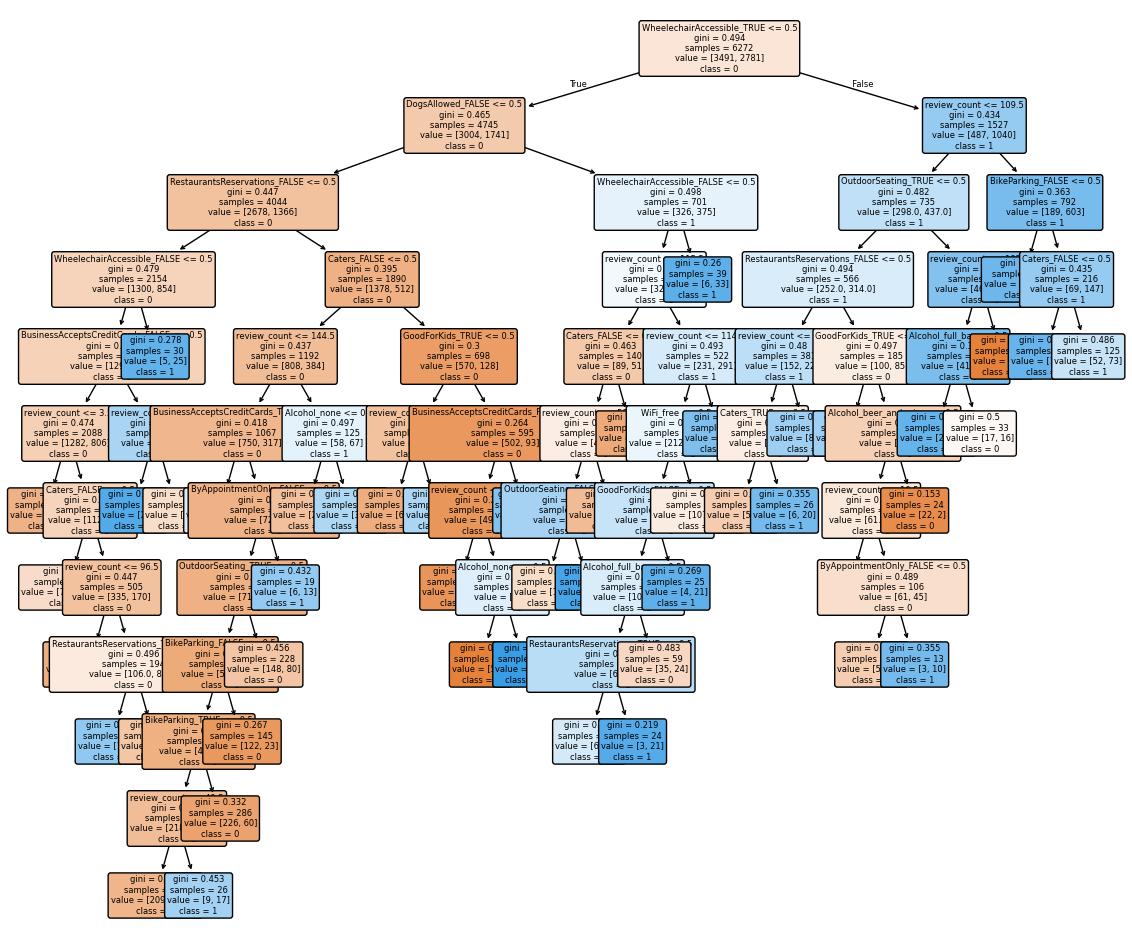

In [8]:
# Build a classification decision tree
dtc = DecisionTreeClassifier(min_samples_leaf=5, 
                             ccp_alpha=best_alpha,
                             random_state = 88)

dtc = dtc.fit(X_train, y_train_classification)
pred_tree = dtc.predict(X_test)

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print('Node count =', dtc.tree_.node_count)
plt.figure(figsize=(14,12))
plot_tree(dtc, 
          feature_names=X_train.columns, 
          class_names=['0','1'], 
          filled=True,
          impurity=True,
          rounded=True,
          fontsize=6) 
plt.show()

**Problem 2 - C) - i)**

In [9]:
# Build a simple majority-vote (hard-voting) ensemble
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pred_ols = (model_ols.predict(X_test) >= 4).astype(int)
pred_logit = (model_logit.predict(X_test) >= 0.5).astype(int) # set the threshold probability as 0.5
pred_tree = dtc.predict(X_test)

preds = np.vstack([pred_ols, pred_logit, pred_tree])
pred_ensemble = (np.mean(preds, axis=0) >= 0.5).astype(int) # follow the majority

y_true = test_encoded['fourOrAbove']

print("=== Ensemble Model Performance ===")
print(f"Accuracy: {accuracy_score(y_true, pred_ensemble):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, pred_ensemble))

=== Ensemble Model Performance ===
Accuracy: 0.6804

Confusion Matrix:
[[1347  168]
 [ 691  482]]


**Problemm 2 - C) - ii)**

In [10]:
# Build a vanilla bagging model (no feature randomization)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

n_features = train_encoded.drop(columns=['stars', 'fourOrAbove']).shape[1]

bagging_model = RandomForestClassifier(
    n_estimators=100,
    max_features=n_features,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train_classification)

from pprint import pprint
pprint(bagging_model.get_params())

from sklearn.metrics import classification_report, accuracy_score
pred_bagging = bagging_model.predict(X_test)
y_test_classification = test_encoded['fourOrAbove']
print("Accuracy:", accuracy_score(y_test_classification, pred_bagging))
print("\nClassification Report:\n", classification_report(y_test_classification, pred_bagging))

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 25,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}
Accuracy: 0.6529017857142857

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.73      0.70      1515
           1       0.61      0.55      0.58      1173

    accuracy                           0.65      2688
   macro avg       0.65      0.64      0.64      2688
weighted avg       0.65      0.65      0.65      2688



Fitting 5 folds for each of 30 candidates, totalling 150 fits

===== Random Forest CV Results =====
Best Parameters: {'max_features': 'log2', 'min_samples_leaf': 4, 'n_estimators': 200}
Best CV Accuracy: 0.686863137561397

===== Random Forest Test Results =====
Accuracy: 0.6878720238095238

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.83      0.75      1515
           1       0.69      0.51      0.59      1173

    accuracy                           0.69      2688
   macro avg       0.69      0.67      0.67      2688
weighted avg       0.69      0.69      0.68      2688



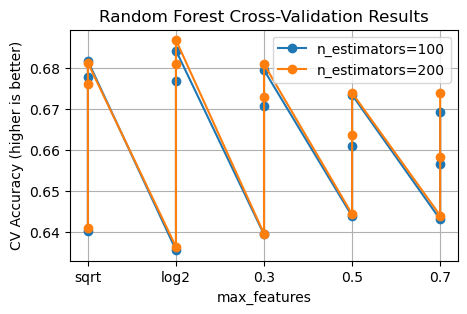

In [11]:
# Build a random forest model

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Define the Random Forest and hyperparameter grid 
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'min_samples_leaf': [1, 2, 4]
}

# Run GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',  
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train_classification)

# Inspect best hyperparameters
print("\n===== Random Forest CV Results =====")
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Evaluate best model on the test set
best_rf = grid_search.best_estimator_
pred_rf = best_rf.predict(X_test)

print("\n===== Random Forest Test Results =====")
print("Accuracy:", accuracy_score(y_test_classification, pred_rf))
print("\nClassification Report:\n", classification_report(y_test_classification, pred_rf))

# Visualize Cross-Validation Results
cv_results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(5,3))
for n_est in param_grid['n_estimators']:
    subset = cv_results[cv_results['param_n_estimators'] == n_est]
    plt.plot(
        subset['param_max_features'].astype(str),
        subset['mean_test_score'],
        marker='o',
        label=f'n_estimators={n_est}'
    )

plt.xlabel('max_features')
plt.ylabel('CV Accuracy (higher is better)')
plt.title('Random Forest Cross-Validation Results')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Compare performance of bagging and random forest
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import f1_score

bag_mae = mean_absolute_error(y_test_classification, pred_bagging)
bag_rmse = np.sqrt(mean_squared_error(y_test_classification, pred_bagging))

rf_mae = mean_absolute_error(y_test_classification, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_classification, pred_rf))

bag_acc = accuracy_score(y_test_classification, pred_bagging)
bag_f1 = f1_score(y_test_classification, pred_bagging)

rf_acc = accuracy_score(y_test_classification, pred_rf)
rf_f1 = f1_score(y_test_classification, pred_rf)

print("\n===== Bagging vs Random Forest Comparison =====")
print("---- Regression-style metrics ----")
print(f"Bagging MAE: {bag_mae:.4f} | RMSE: {bag_rmse:.4f}")
print(f"Random Forest MAE: {rf_mae:.4f} | RMSE: {rf_rmse:.4f}")

print("\n---- Classification metrics ----")
print(f"Bagging Accuracy: {bag_acc:.4f} | F1-score: {bag_f1:.4f}")
print(f"Random Forest Accuracy: {rf_acc:.4f} | F1-score: {rf_f1:.4f}")

if rf_rmse < bag_rmse and rf_acc > bag_acc:
    print("\n Random Forest performed better overall — lower RMSE and higher accuracy/F1 indicate better generalization.")
elif rf_rmse > bag_rmse and rf_acc < bag_acc:
    print("\n Bagging performed better overall — Random Forest did not improve performance in this case.")
else:
    print("\n Performance is mixed — Bagging and Random Forest have similar performance depending on the metric.")


===== Bagging vs Random Forest Comparison =====
---- Regression-style metrics ----
Bagging MAE: 0.3471 | RMSE: 0.5892
Random Forest MAE: 0.3121 | RMSE: 0.5587

---- Classification metrics ----
Bagging Accuracy: 0.6529 | F1-score: 0.5799
Random Forest Accuracy: 0.6879 | F1-score: 0.5869

 Random Forest performed better overall — lower RMSE and higher accuracy/F1 indicate better generalization.


**Problem 2 - c) -iii)**

Fitting 5 folds for each of 16 candidates, totalling 80 fits

===== Best Parameters =====
{'max_leaf_nodes': 10, 'n_estimators': 300}
Best CV Accuracy: 0.6792096685030213


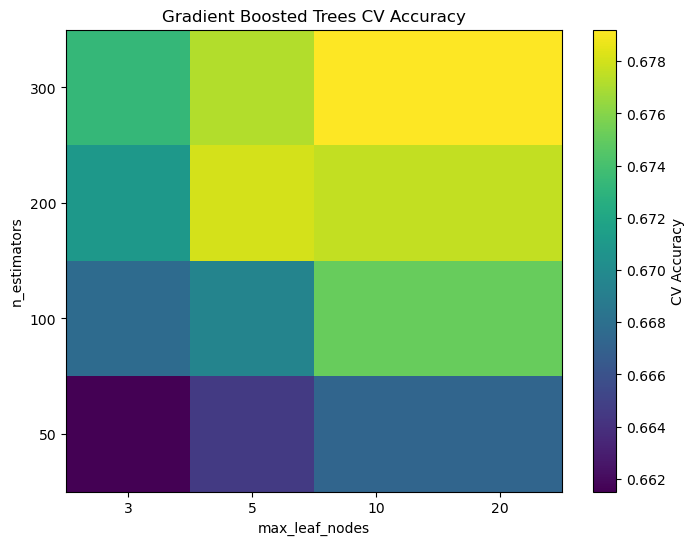

In [14]:
# GRADIENT BOOSTED TREE with CV and Visualization

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score

gbc = GradientBoostingClassifier(
    learning_rate=0.1, 
    random_state=42
)

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_leaf_nodes': [3, 5, 10, 20]
}

grid_search = GridSearchCV(
    gbc,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train_classification)

best_gbc = grid_search.best_estimator_
pred_gbc = best_gbc.predict(X_test)

print("\n===== Best Parameters =====")
print(grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Visualize CV RMSE across parameters ===
cv_results = pd.DataFrame(grid_search.cv_results_)

# Pivot table: n_estimators x max_leaf_nodes → mean_test_score (accuracy)
pivot_table = cv_results.pivot(
    index='param_n_estimators',
    columns='param_max_leaf_nodes',
    values='mean_test_score'
)

plt.figure(figsize=(8,6))
plt.imshow(pivot_table, cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(label='CV Accuracy')
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.xlabel('max_leaf_nodes')
plt.ylabel('n_estimators')
plt.title('Gradient Boosted Trees CV Accuracy')
plt.show()

**Problem 2 - c) - iv)**

In [15]:
# Evaluate the performance of different classificatino models

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return acc, tpr, fpr

results = []
model_dict = {
    "OLS (thresholded)": pred_ols,
    "Logistic Regression": pred_logit,
    "Decision Tree": pred_tree,
    "Hard Voting Ensemble": pred_ensemble,
    "Vanilla Bagging": pred_bagging,
    "Random Forest": pred_rf,
    "Gradient Boosting": pred_gbc
}

for name, preds in model_dict.items():
    acc, tpr, fpr = get_metrics(y_test_classification, preds)
    results.append({
        "Model": name,
        "Accuracy": acc,
        "TPR": tpr,
        "FPR": fpr
    })

results_df = pd.DataFrame(results)

print("\n===== Classification Performance Summary =====")
print(results_df.round(4))


===== Classification Performance Summary =====
                  Model  Accuracy     TPR     FPR
0     OLS (thresholded)    0.6347  0.2123  0.0383
1   Logistic Regression    0.6793  0.4876  0.1723
2         Decision Tree    0.6719  0.4527  0.1584
3  Hard Voting Ensemble    0.6804  0.4109  0.1109
4       Vanilla Bagging    0.6529  0.5490  0.2667
5         Random Forest    0.6879  0.5081  0.1729
6     Gradient Boosting    0.6860  0.5175  0.1835


**Problem 2 - d) - i)**

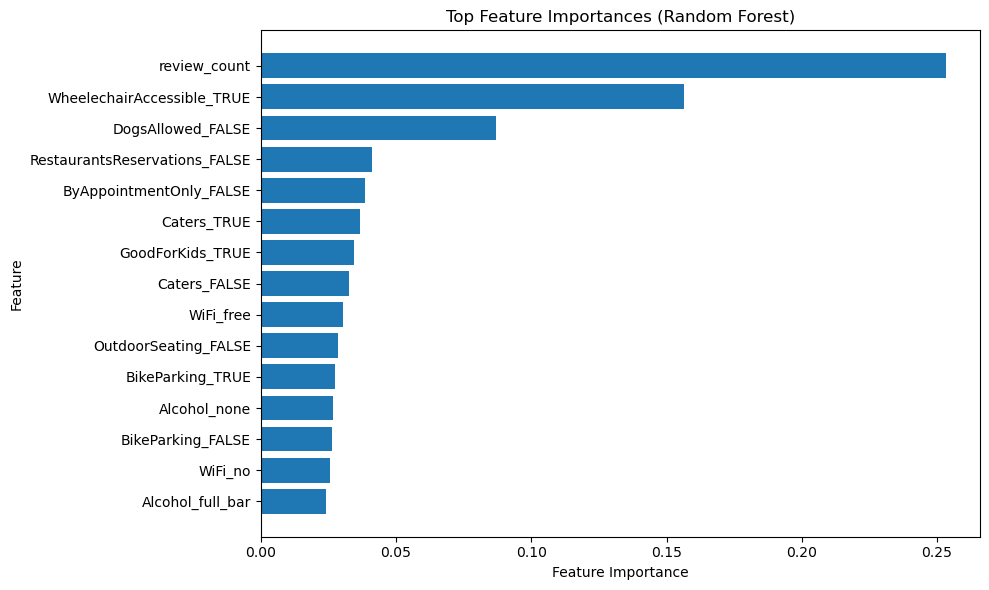

In [17]:
# Feature importance for Random Forest model
importances = best_rf.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'][:top_n][::-1], feat_imp['Importance'][:top_n][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

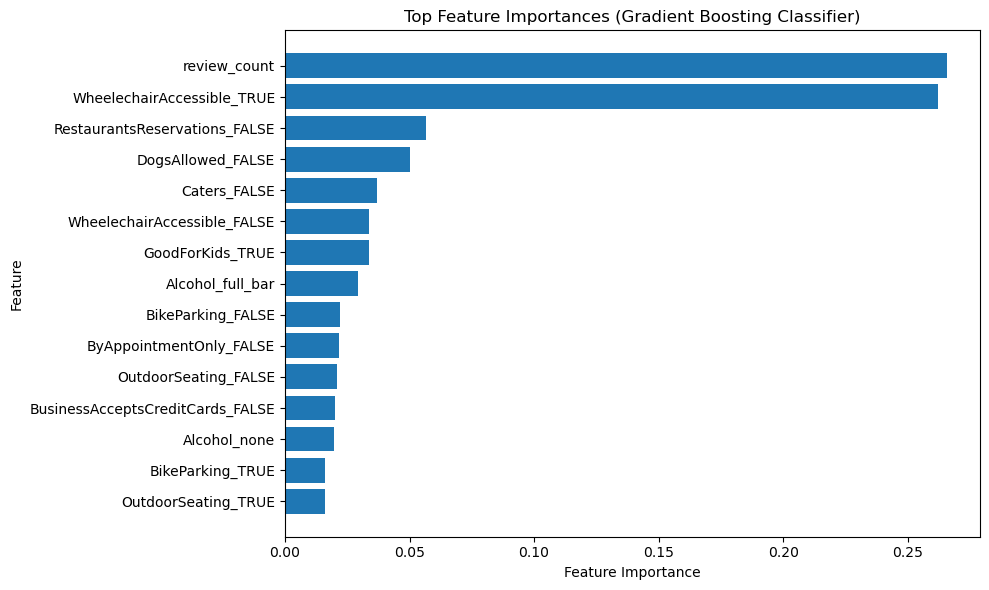

In [18]:
# Feature importance for Gradient Boosted Tree model
importances = best_gbc.feature_importances_
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'][:top_n][::-1], feat_imp['Importance'][:top_n][::-1])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top Feature Importances (Gradient Boosting Classifier)')
plt.tight_layout()
plt.show()